In [1]:
import pandas as pd
import numpy as np

# 1. Gerçek veriyi senin belirlediğin dosya adıyla okuyalım
print("Veri okunuyor, dosya büyük olduğu için birkaç saniye sürebilir...")
df_real = pd.read_csv("../data/raw/malicious_phish.csv")

print("Gerçek veri başarıyla yüklendi!")
print(f"Toplam Satır Sayısı: {df_real.shape[0]}")

# 2. Veri setindeki orijinal kategorilere bakalım
print("\nOrijinal Sınıf (Type) Dağılımı:")
print(df_real['type'].value_counts())

# 3. Hedef değişkeni (Label) oluşturalım: 'benign' -> 0, diğerleri -> 1
df_real['label'] = df_real['type'].apply(lambda x: 0 if x == 'benign' else 1)

print("\nModel İçin Hazırlanan Yeni İkili Sınıf (Label) Dağılımı:")
print(df_real['label'].value_counts())

Veri okunuyor, dosya büyük olduğu için birkaç saniye sürebilir...
Gerçek veri başarıyla yüklendi!
Toplam Satır Sayısı: 651191

Orijinal Sınıf (Type) Dağılımı:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

Model İçin Hazırlanan Yeni İkili Sınıf (Label) Dağılımı:
label
0    428103
1    223088
Name: count, dtype: int64


In [2]:
# 1. URL Uzunluğu
df_real['url_length'] = df_real['url'].apply(len)

# 2. HTTPS kontrolü (Zararlı sitelerin çoğunda https yoktur, HTTP veya IP kullanırlar)
df_real['has_https'] = df_real['url'].apply(lambda x: 1 if 'https://' in str(x) else 0)

# 3. Tire (-) sayısı
df_real['hyphen_count'] = df_real['url'].apply(lambda x: str(x).count('-'))

# 4. Rakam sayısı (Yeni ve çok güçlü bir özellik!)
df_real['digit_count'] = df_real['url'].apply(lambda x: sum(c.isdigit() for c in str(x)))

# 5. Şüpheli Kelime Kontrolü (İngilizce veri seti olduğu için kelimeleri İngilizce seçtik)
suspicious_keywords = ['login', 'verify', 'update', 'secure', 'account', 'bank', 'free', 'bonus', 'admin']

def check_suspicious(url):
    url_lower = str(url).lower()
    for word in suspicious_keywords:
        if word in url_lower:
            return 1
    return 0

print("Özellikler (Features) hesaplanıyor...")
print("650 BİN satır olduğu için bu işlem bilgisayarının hızına göre 10-30 saniye arası sürebilir. Lütfen bekle...")

df_real['suspicious_keyword'] = df_real['url'].apply(check_suspicious)

print("\nFeature Engineering tamamlandı! Verinin modele girmeye hazır hali:")
display(df_real.head(10))

Özellikler (Features) hesaplanıyor...
650 BİN satır olduğu için bu işlem bilgisayarının hızına göre 10-30 saniye arası sürebilir. Lütfen bekle...

Feature Engineering tamamlandı! Verinin modele girmeye hazır hali:


,url,type,label,url_length,has_https,hyphen_count,digit_count,suspicious_keyword
0,br-icloud.com.br,phishing,1,16,0,1,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,0,1,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,0,1,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,1,88,0,1,7,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,0,1,22,0
5,http://buzzfil.net/m/show-art/ils-etaient-loin...,benign,0,118,0,16,1,0
6,espn.go.com/nba/player/_/id/3457/brandon-rush,benign,0,45,0,1,4,0
7,yourbittorrent.com/?q=anthony-hamilton-soulife,benign,0,46,0,2,0,0
8,http://www.pashminaonline.com/pure-pashminas,defacement,1,44,0,1,0,0
9,allmusic.com/album/crazy-from-the-heat-r16990,benign,0,45,0,4,5,0


Model eğitiliyor...
DİKKAT: 650 bin satır olduğu için bu işlem bilgisayarında 1 ile 3 dakika arası sürebilir. Lütfen sabırla bekle...

--- GERÇEK DÜNYA MODEL KARNESİ ---
              precision    recall  f1-score   support

           0       0.78      0.93      0.85     85778
           1       0.79      0.48      0.59     44461

    accuracy                           0.78    130239
   macro avg       0.78      0.71      0.72    130239
weighted avg       0.78      0.78      0.76    130239



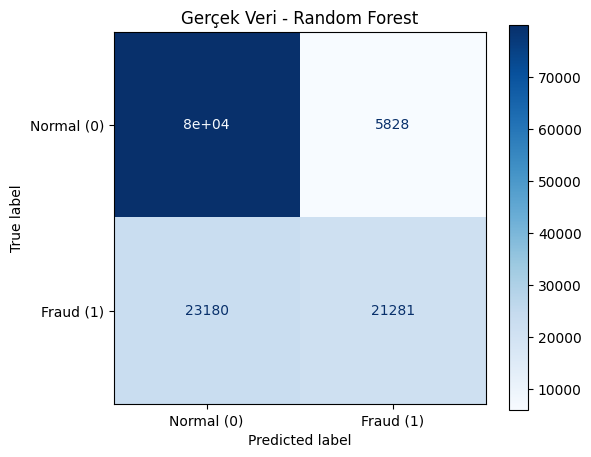

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Özellikleri (X) ve Hedefi (y) ayırıyoruz
# Metin içeren 'url' ve 'type' sütunlarını atıyoruz, model sadece sayılarla çalışır
X = df_real.drop(columns=['url', 'type', 'label'])
y = df_real['label']

# 2. Veriyi %80 Eğitim, %20 Test olarak bölüyoruz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Model eğitiliyor...")
print("DİKKAT: 650 bin satır olduğu için bu işlem bilgisayarında 1 ile 3 dakika arası sürebilir. Lütfen sabırla bekle...")

# 3. Modeli Tanımlama ve Eğitme
# n_jobs=-1 parametresi, bilgisayarının tüm işlemci çekirdeklerini kullanarak eğitimi hızlandırır
rf_model_real = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model_real.fit(X_train, y_train)

# 4. Test verisi üzerinde tahmin yapma
y_pred_real = rf_model_real.predict(X_test)

print("\n--- GERÇEK DÜNYA MODEL KARNESİ ---")
print(classification_report(y_test, y_pred_real))

# 5. Karmaşıklık Matrisini (Confusion Matrix) Çizme
cm = confusion_matrix(y_test, y_pred_real)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Fraud (1)'])
disp.plot(cmap='Blues', ax=ax)

plt.title('Gerçek Veri - Random Forest')
plt.grid(False)
plt.show()

In [6]:
import joblib

# 1. MODELİ KAYDETME (Serialization)
model_path = "../models/rf_fraud_model.joblib"
joblib.dump(rf_model_real, model_path)
print(f"Model başarıyla kaydedildi: {model_path}\n")

# 2. CANLI TEST FONKSİYONU (Inference)
def test_new_url(url):
    # Modele eğitimde hangi özellikleri (features) gösterdiysek,
    # yeni gelen linkten de o özellikleri aynı sırayla çıkarmak ZORUNDAYIZ.
    
    url_length = len(url)
    has_https = 1 if 'https://' in url else 0
    hyphen_count = url.count('-')
    digit_count = sum(c.isdigit() for c in url)
    
    suspicious_keywords = ['login', 'verify', 'update', 'secure', 'account', 'bank', 'free', 'bonus', 'admin']
    suspicious_keyword = 1 if any(word in url.lower() for word in suspicious_keywords) else 0
    
    # Modele vereceğimiz 1 satırlık tabloyu oluşturuyoruz
    features = pd.DataFrame([[url_length, has_https, hyphen_count, digit_count, suspicious_keyword]], 
                            columns=['url_length', 'has_https', 'hyphen_count', 'digit_count', 'suspicious_keyword'])
    
    # Modeli kullanarak tahmin (predict) ve olasılık (predict_proba) hesaplama
    prediction = rf_model_real.predict(features)[0]
    probability = rf_model_real.predict_proba(features)[0][1] * 100 # Sınıf 1 (Fraud) olma olasılığı
    
    # Sonucu ekrana yazdır
    print(f"İncelenen URL: {url}")
    if prediction == 1:
        print(f"🚨 RİSKLİ! (Zararlı Olma İhtimali: %{probability:.1f})")
    else:
        print(f"✅ GÜVENLİ. (Zararlı Olma İhtimali: %{probability:.1f})")
    print("-" * 40)

# 3. KENDİ TESTLERİMİZİ YAPALIM
# Temiz bir site
test_new_url("https://www.sakarya.edu.tr")

# Rakam dolu, https olmayan şüpheli bir site
test_new_url("http://192.168.1.55/admin-login-4421")

# Oltalama (Phishing) taklidi yapan bir site
test_new_url("http://update-hesap-onay-8821.com/login")

Model başarıyla kaydedildi: ../models/rf_fraud_model.joblib

İncelenen URL: https://www.sakarya.edu.tr
🚨 RİSKLİ! (Zararlı Olma İhtimali: %100.0)
----------------------------------------
İncelenen URL: http://192.168.1.55/admin-login-4421
🚨 RİSKLİ! (Zararlı Olma İhtimali: %68.0)
----------------------------------------
İncelenen URL: http://update-hesap-onay-8821.com/login
🚨 RİSKLİ! (Zararlı Olma İhtimali: %71.2)
----------------------------------------
